# Notebook 02 — Análise Exploratória

**Projeto:** Mapa da Inseminação Artificial no Brasil  
**Autor:** Mateus Martins — Médico Veterinário

Aqui é onde os dados viram história. Vou gerar 8 gráficos que contam o panorama
da inseminação artificial no Brasil — de onde veio, onde está, e pra onde pode ir.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import os
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')

# Paleta de cores consistente
AZUL = '#2E75B6'
VERDE = '#548235'
VERMELHO = '#C0504D'
AMARELO = '#E6A817'
CINZA = '#7F7F7F'
LARANJA = '#ED7D31'

CORES_REGIAO = {
    'Norte': '#E6A817',
    'Nordeste': '#C0504D',
    'Sudeste': '#2E75B6',
    'Sul': '#548235',
    'Centro-Oeste': '#ED7D31'
}

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['figure.dpi'] = 150

os.makedirs('plots', exist_ok=True)
print('Setup OK')

Setup OK


In [2]:
# Carregar datasets gerados no notebook 01
df = pd.read_csv('data/processed/dataset_ia_brasil.csv')
asbia_brasil = pd.read_csv('data/raw/asbia_dados_compilados.csv')

print(f'Dataset principal: {df.shape}')
print(f'Série temporal ASBIA: {asbia_brasil.shape}')
df.head()

Dataset principal: (27, 10)
Série temporal ASBIA: (15, 6)


,sigla_uf,uf,rebanho,regiao,pct_femeas_inseminadas_corte,pct_femeas_inseminadas_leite,femeas_estimadas,femeas_inseminadas_est,femeas_nao_inseminadas,potencial_doses
0,MT,Mato Grosso,34245000,Centro-Oeste,24.3,6.0,18834750,4576844,14257906,4277371
1,GO,Goiás,24015000,Centro-Oeste,28.5,10.0,13208250,3764351,9443899,2833169
2,PA,Pará,23580000,Norte,11.8,2.5,12969000,1530342,11438658,3431597
3,MG,Minas Gerais,23105000,Sudeste,22.0,14.0,12707750,2795705,9912045,2973613
4,MS,Mato Grosso do Sul,20150000,Centro-Oeste,26.8,8.5,11082500,2970110,8112390,2433717


## Gráfico 1 — Evolução da IATF no Brasil (2010-2024)

Esse é o gráfico que mostra a história da IATF no Brasil. De 6 milhões de protocolos 
em 2010 para 23 milhões em 2024 — quase 4x. Mas o que mais chama atenção é como 
a curva acompanha o preço da arroba. Quando o boi paga bem, o pecuarista investe 
em genética.

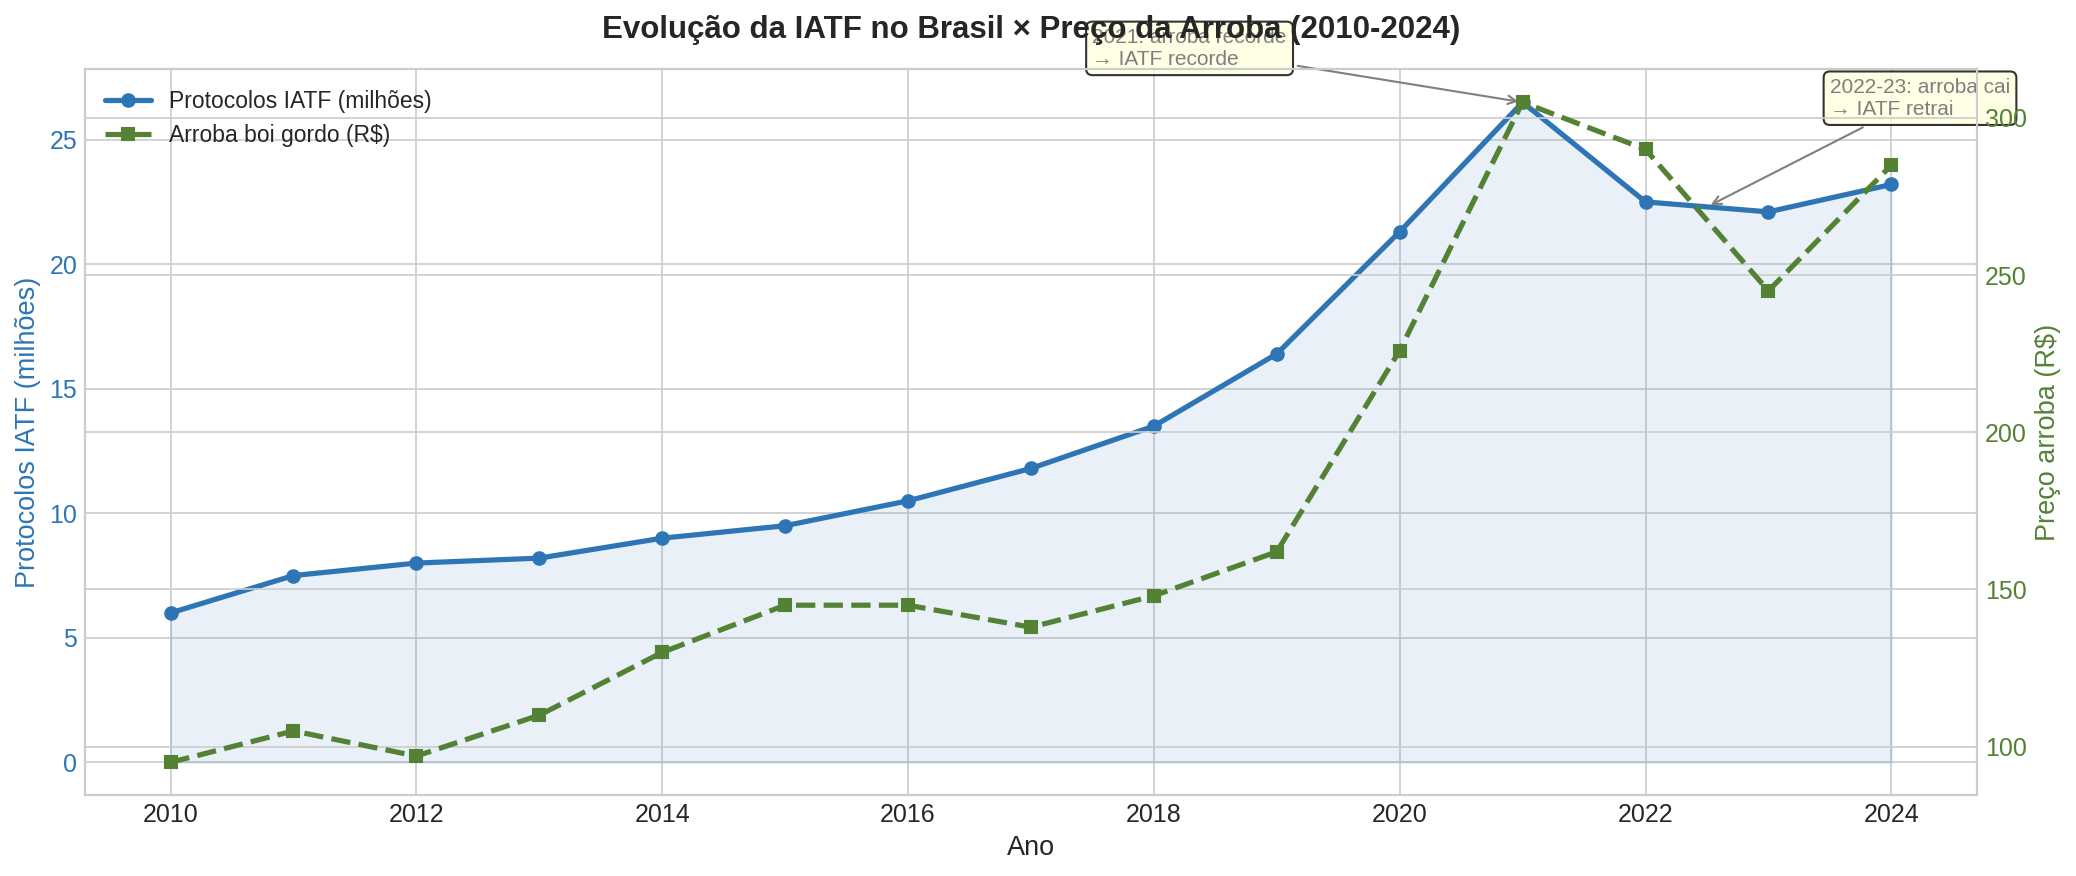

Salvo: plots/01_evolucao_iatf_brasil.png


In [3]:
fig, ax1 = plt.subplots(figsize=(14, 6))

# Eixo esquerdo: protocolos IATF
ax1.plot(asbia_brasil['ano'], asbia_brasil['protocolos_iatf_milhoes'], 
         color=AZUL, linewidth=2.5, marker='o', markersize=6, label='Protocolos IATF (milhões)')
ax1.fill_between(asbia_brasil['ano'], asbia_brasil['protocolos_iatf_milhoes'], alpha=0.1, color=AZUL)
ax1.set_xlabel('Ano', fontsize=13)
ax1.set_ylabel('Protocolos IATF (milhões)', color=AZUL, fontsize=13)
ax1.tick_params(axis='y', labelcolor=AZUL)

# Eixo direito: preço da arroba
ax2 = ax1.twinx()
ax2.plot(asbia_brasil['ano'], asbia_brasil['preco_arroba_media_anual'],
         color=VERDE, linewidth=2.5, marker='s', markersize=6, linestyle='--', label='Arroba boi gordo (R$)')
ax2.set_ylabel('Preço arroba (R$)', color=VERDE, fontsize=13)
ax2.tick_params(axis='y', labelcolor=VERDE)

# Anotações
ax1.annotate('2021: arroba recorde\n→ IATF recorde', xy=(2021, 26.5), xytext=(2017.5, 28),
            arrowprops=dict(arrowstyle='->', color=CINZA), fontsize=10, color=CINZA,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.8))

ax1.annotate('2022-23: arroba cai\n→ IATF retrai', xy=(2022.5, 22.3), xytext=(2023.5, 26),
            arrowprops=dict(arrowstyle='->', color=CINZA), fontsize=10, color=CINZA,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.8))

ax1.set_title('Evolução da IATF no Brasil × Preço da Arroba (2010-2024)', fontsize=15, fontweight='bold', pad=15)

# Legenda combinada
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=11)

plt.tight_layout()
plt.savefig('plots/01_evolucao_iatf_brasil.png', dpi=150, bbox_inches='tight')
plt.show()
print('Salvo: plots/01_evolucao_iatf_brasil.png')

## Gráfico 2 — % de Fêmeas Inseminadas por Região

O Sul lidera, o Norte e Nordeste ficam abaixo da média. Mas o Nordeste é 
heterogêneo — Alagoas puxa a média pra cima enquanto Piauí e Maranhão a derrubam.

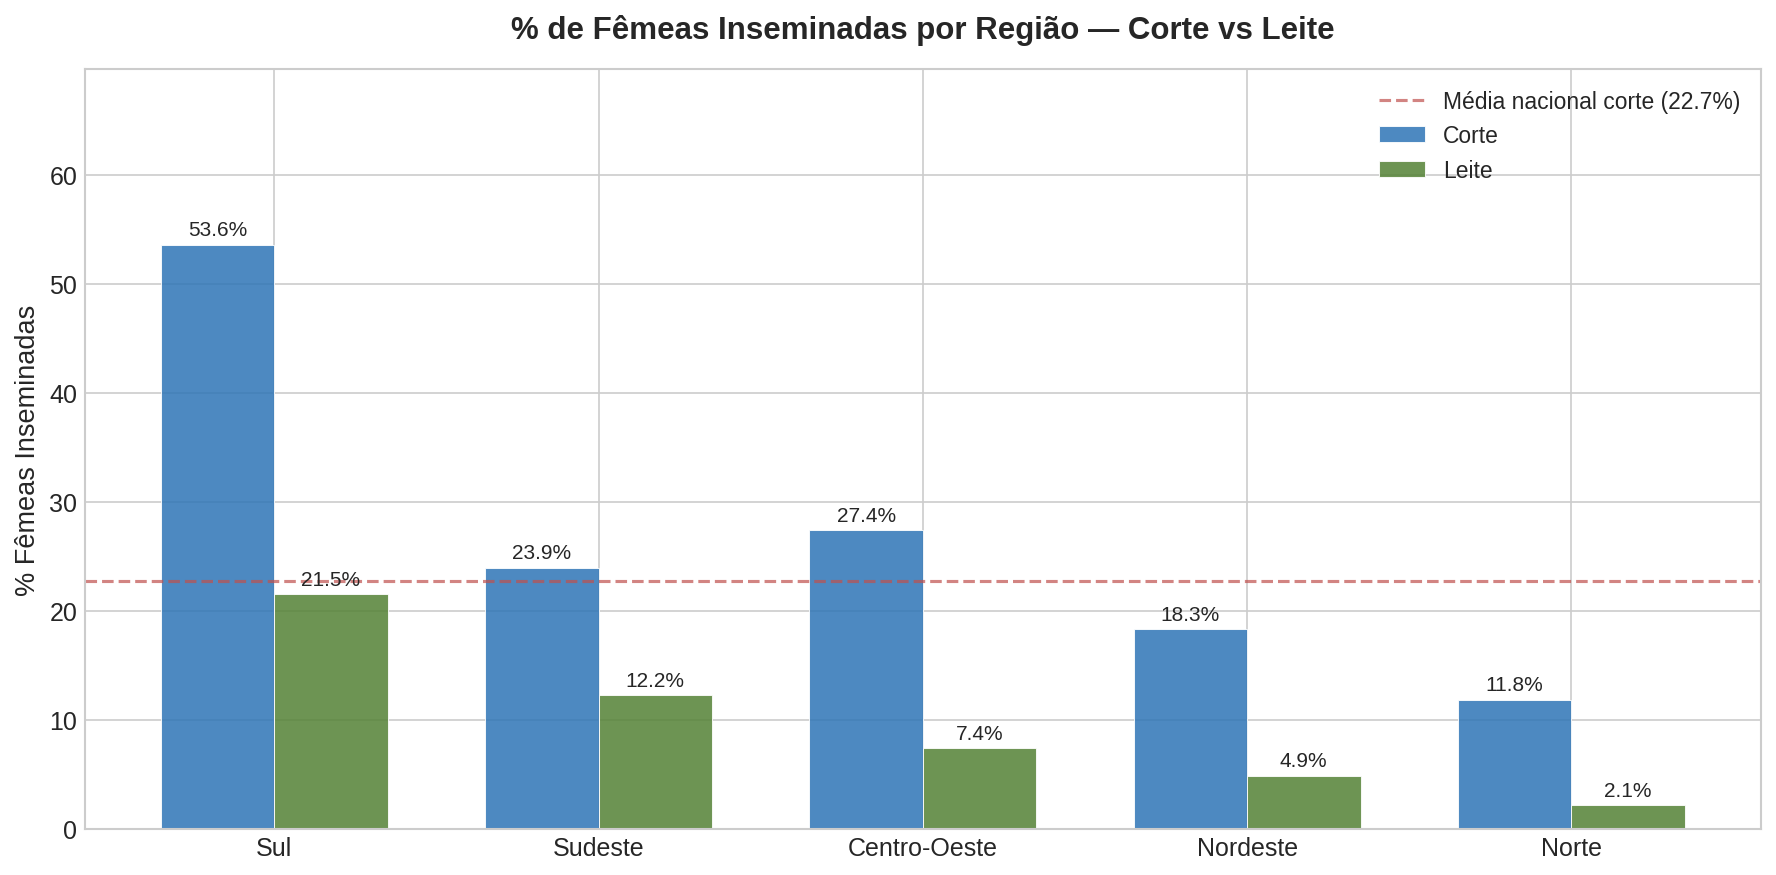

Salvo: plots/02_inseminacao_por_regiao.png


In [4]:
# Calcular médias por região (corte e leite)
regioes_order = ['Sul', 'Sudeste', 'Centro-Oeste', 'Nordeste', 'Norte']
media_corte = df.groupby('regiao')['pct_femeas_inseminadas_corte'].mean()
media_leite = df.groupby('regiao')['pct_femeas_inseminadas_leite'].mean()

fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(regioes_order))
width = 0.35

bars1 = ax.bar(x - width/2, [media_corte[r] for r in regioes_order], width, 
               label='Corte', color=AZUL, alpha=0.85, edgecolor='white', linewidth=0.5)
bars2 = ax.bar(x + width/2, [media_leite[r] for r in regioes_order], width,
               label='Leite', color=VERDE, alpha=0.85, edgecolor='white', linewidth=0.5)

# Média nacional
media_nac = df['pct_femeas_inseminadas_corte'].mean()
ax.axhline(y=media_nac, color=VERMELHO, linestyle='--', linewidth=1.5, alpha=0.7,
           label=f'Média nacional corte ({media_nac:.1f}%)')

# Labels nas barras
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.5,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=10)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.5,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=10)

ax.set_title('% de Fêmeas Inseminadas por Região — Corte vs Leite', fontsize=15, fontweight='bold', pad=15)
ax.set_ylabel('% Fêmeas Inseminadas', fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels(regioes_order, fontsize=12)
ax.legend(fontsize=11)
ax.set_ylim(0, max(media_corte.max(), media_leite.max()) * 1.3)

plt.tight_layout()
plt.savefig('plots/02_inseminacao_por_regiao.png', dpi=150, bbox_inches='tight')
plt.show()
print('Salvo: plots/02_inseminacao_por_regiao.png')

## Gráfico 3 — Ranking de UFs: % de Fêmeas Inseminadas

O dado mais surpreendente desse projeto: **Alagoas com 79,5%** — segundo lugar 
nacional, atrás apenas de Santa Catarina. Um estado pequeno do Nordeste com 
adoção altíssima. Pra um veterinário, isso é contraintuitivo.

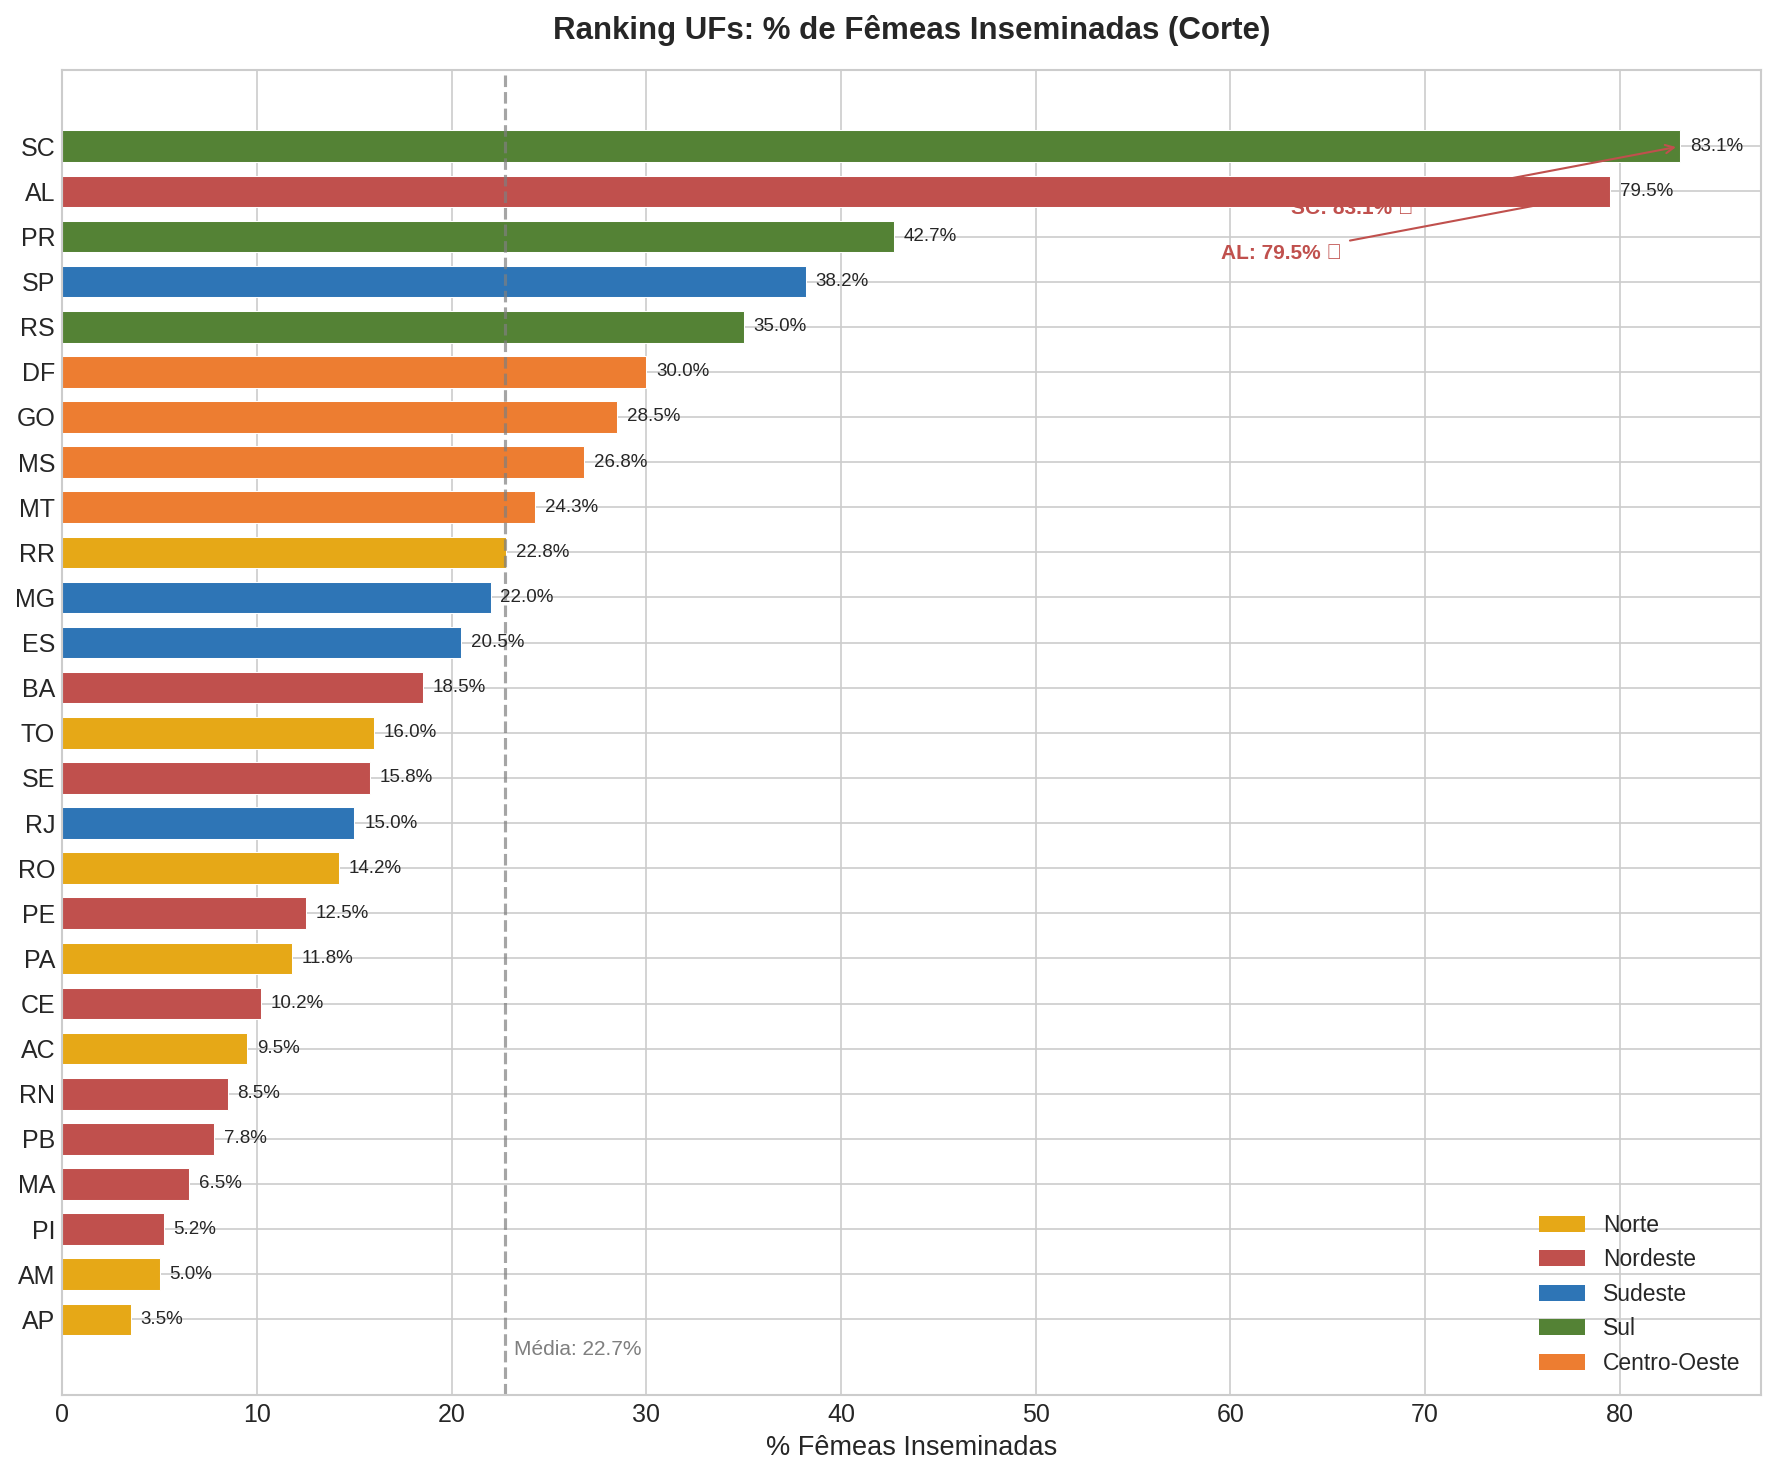

Salvo: plots/03_ranking_ufs.png


In [5]:
df_sorted = df.sort_values('pct_femeas_inseminadas_corte', ascending=True)

fig, ax = plt.subplots(figsize=(12, 10))

colors = [CORES_REGIAO[r] for r in df_sorted['regiao']]
bars = ax.barh(df_sorted['sigla_uf'], df_sorted['pct_femeas_inseminadas_corte'],
               color=colors, edgecolor='white', linewidth=0.5, height=0.7)

# Valores nas barras
for bar, val in zip(bars, df_sorted['pct_femeas_inseminadas_corte']):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=9)

# Média nacional
ax.axvline(x=media_nac, color=CINZA, linestyle='--', linewidth=1.5, alpha=0.7)
ax.text(media_nac + 0.5, -0.8, f'Média: {media_nac:.1f}%', fontsize=10, color=CINZA)

# Destaques SC e AL
for uf, val in [('SC', 83.1), ('AL', 79.5)]:
    idx = df_sorted[df_sorted['sigla_uf'] == uf].index[0]
    y_pos = list(df_sorted['sigla_uf']).index(uf)
    ax.annotate(f'{uf}: {val}% ★', xy=(val, y_pos), xytext=(val - 20, y_pos - 1.5),
                fontsize=10, fontweight='bold', color=VERMELHO,
                arrowprops=dict(arrowstyle='->', color=VERMELHO))

ax.set_title('Ranking UFs: % de Fêmeas Inseminadas (Corte)', fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('% Fêmeas Inseminadas', fontsize=13)

# Legenda de cores por região
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=c, label=r) for r, c in CORES_REGIAO.items()]
ax.legend(handles=legend_elements, loc='lower right', fontsize=11)

plt.tight_layout()
plt.savefig('plots/03_ranking_ufs.png', dpi=150, bbox_inches='tight')
plt.show()
print('Salvo: plots/03_ranking_ufs.png')

## Gráfico 4 — Foco Nordeste: Inseminação por Estado

O Nordeste não é um bloco homogêneo. Tem pelo menos 3 realidades:
- **Zona da Mata / Litoral** (AL, SE, PE): mais acesso, rebanhos menores, adoção mais alta
- **Cerrado / MATOPIBA** (BA, MA, PI): fronteira agrícola, rebanho crescendo, IA ainda baixa
- **Semiárido** (CE, RN, PB, PI): dificuldades estruturais, baixa adoção

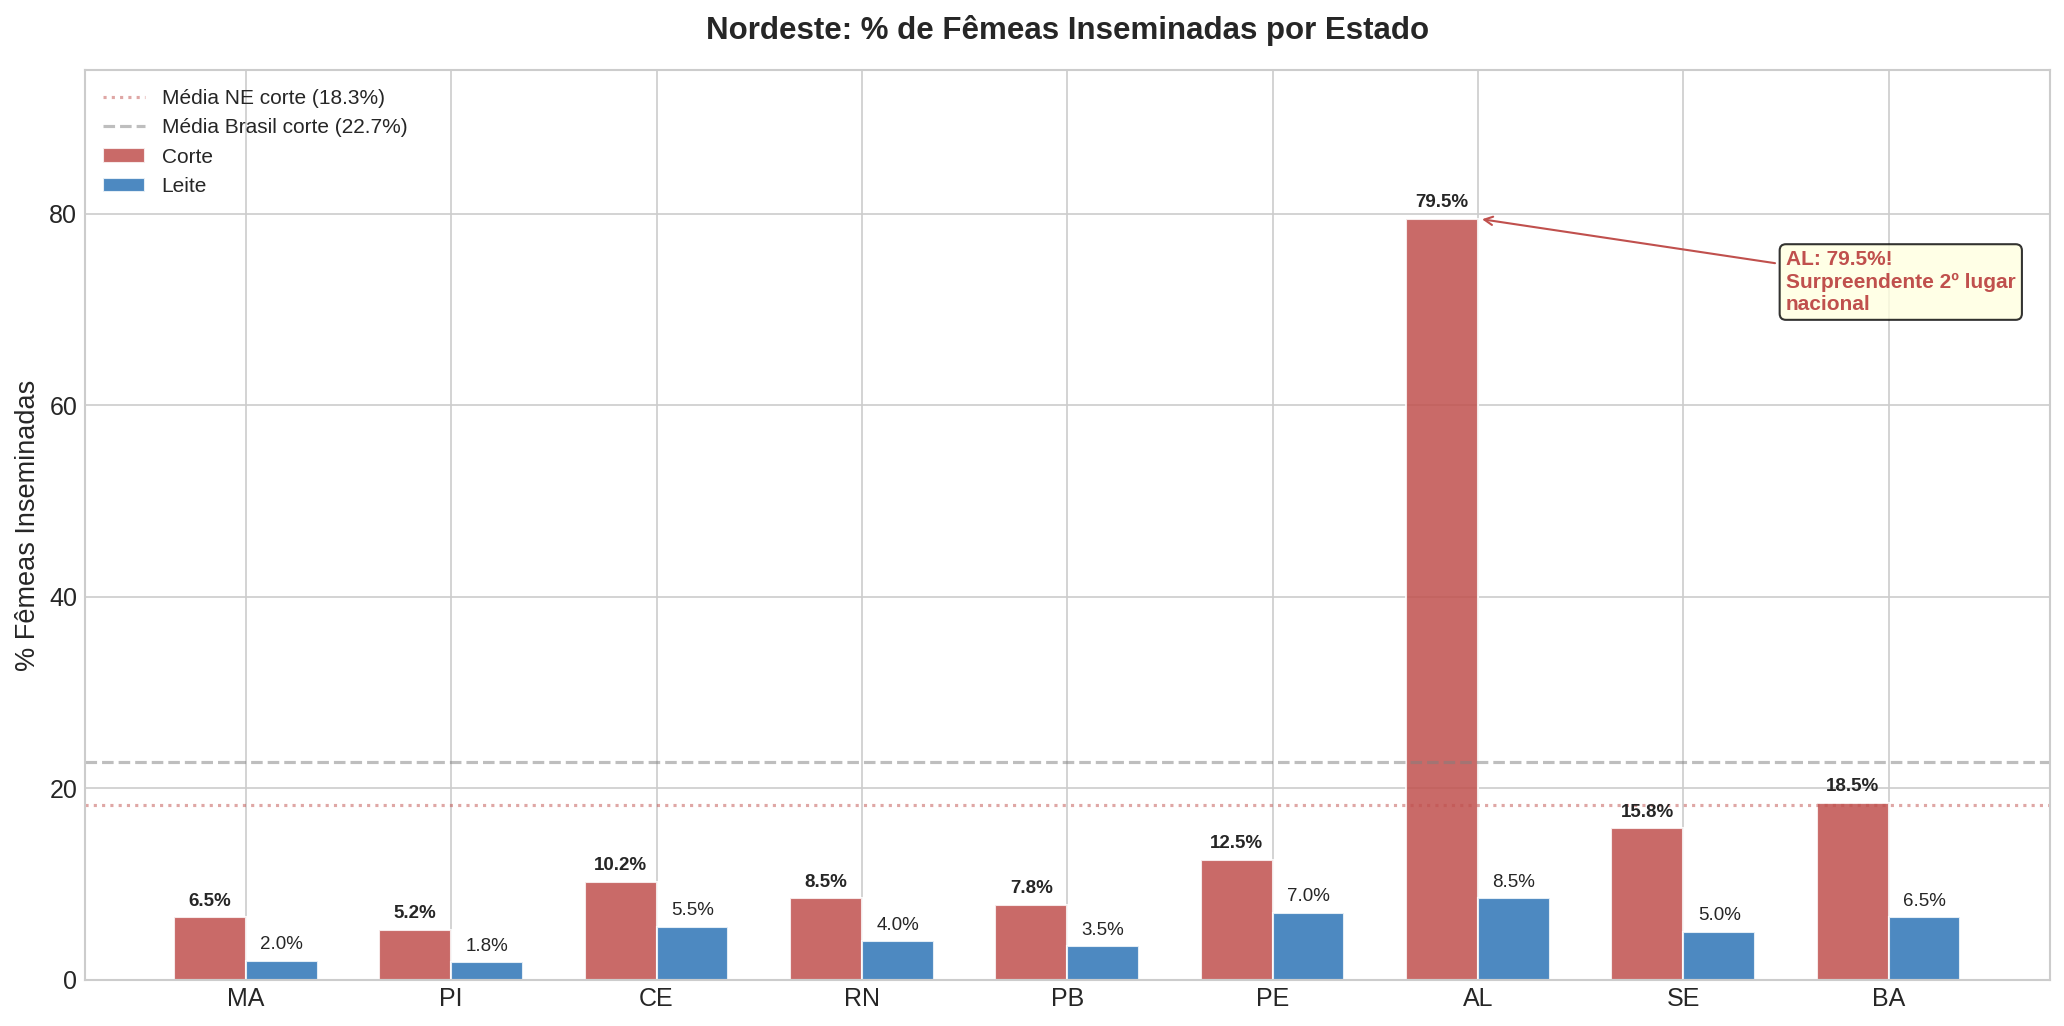

Salvo: plots/04_nordeste_detalhado.png


In [6]:
ne_states = ['MA', 'PI', 'CE', 'RN', 'PB', 'PE', 'AL', 'SE', 'BA']
df_ne = df[df['sigla_uf'].isin(ne_states)].copy()
df_ne['sigla_uf'] = pd.Categorical(df_ne['sigla_uf'], categories=ne_states, ordered=True)
df_ne = df_ne.sort_values('sigla_uf')

fig, ax = plt.subplots(figsize=(14, 7))
x = np.arange(len(ne_states))
width = 0.35

bars1 = ax.bar(x - width/2, df_ne['pct_femeas_inseminadas_corte'], width,
               label='Corte', color=VERMELHO, alpha=0.85, edgecolor='white')
bars2 = ax.bar(x + width/2, df_ne['pct_femeas_inseminadas_leite'], width,
               label='Leite', color=AZUL, alpha=0.85, edgecolor='white')

# Médias
media_ne_corte = df_ne['pct_femeas_inseminadas_corte'].mean()
ax.axhline(y=media_ne_corte, color=VERMELHO, linestyle=':', linewidth=1.5, alpha=0.5,
           label=f'Média NE corte ({media_ne_corte:.1f}%)')
ax.axhline(y=media_nac, color=CINZA, linestyle='--', linewidth=1.5, alpha=0.5,
           label=f'Média Brasil corte ({media_nac:.1f}%)')

# Labels
for bar in bars1:
    if bar.get_height() > 2:
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.8,
                f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')
for bar in bars2:
    if bar.get_height() > 1:
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.8,
                f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=9)

ax.set_title('Nordeste: % de Fêmeas Inseminadas por Estado', fontsize=15, fontweight='bold', pad=15)
ax.set_ylabel('% Fêmeas Inseminadas', fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels(ne_states, fontsize=12)
ax.legend(fontsize=10, loc='upper left')
ax.set_ylim(0, 95)

# Destaque Alagoas
ax.annotate('AL: 79.5%!\nSurpreendente 2º lugar\nnacional', xy=(6, 79.5), xytext=(7.5, 70),
            fontsize=10, color=VERMELHO, fontweight='bold',
            arrowprops=dict(arrowstyle='->', color=VERMELHO),
            bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.8))

plt.tight_layout()
plt.savefig('plots/04_nordeste_detalhado.png', dpi=150, bbox_inches='tight')
plt.show()
print('Salvo: plots/04_nordeste_detalhado.png')

## Gráfico 5 — Potencial Inexplorado por UF (Scatter)

Aqui é onde a coisa fica interessante pra quem vende sêmen ou presta serviço de IATF.

- **Quadrante inferior direito** (rebanho grande + baixa IA) = maior oportunidade
- **Quadrante superior esquerdo** (rebanho menor + alta IA) = mercado mais maduro

PA, BA, MA aparecem como o maior potencial absoluto.

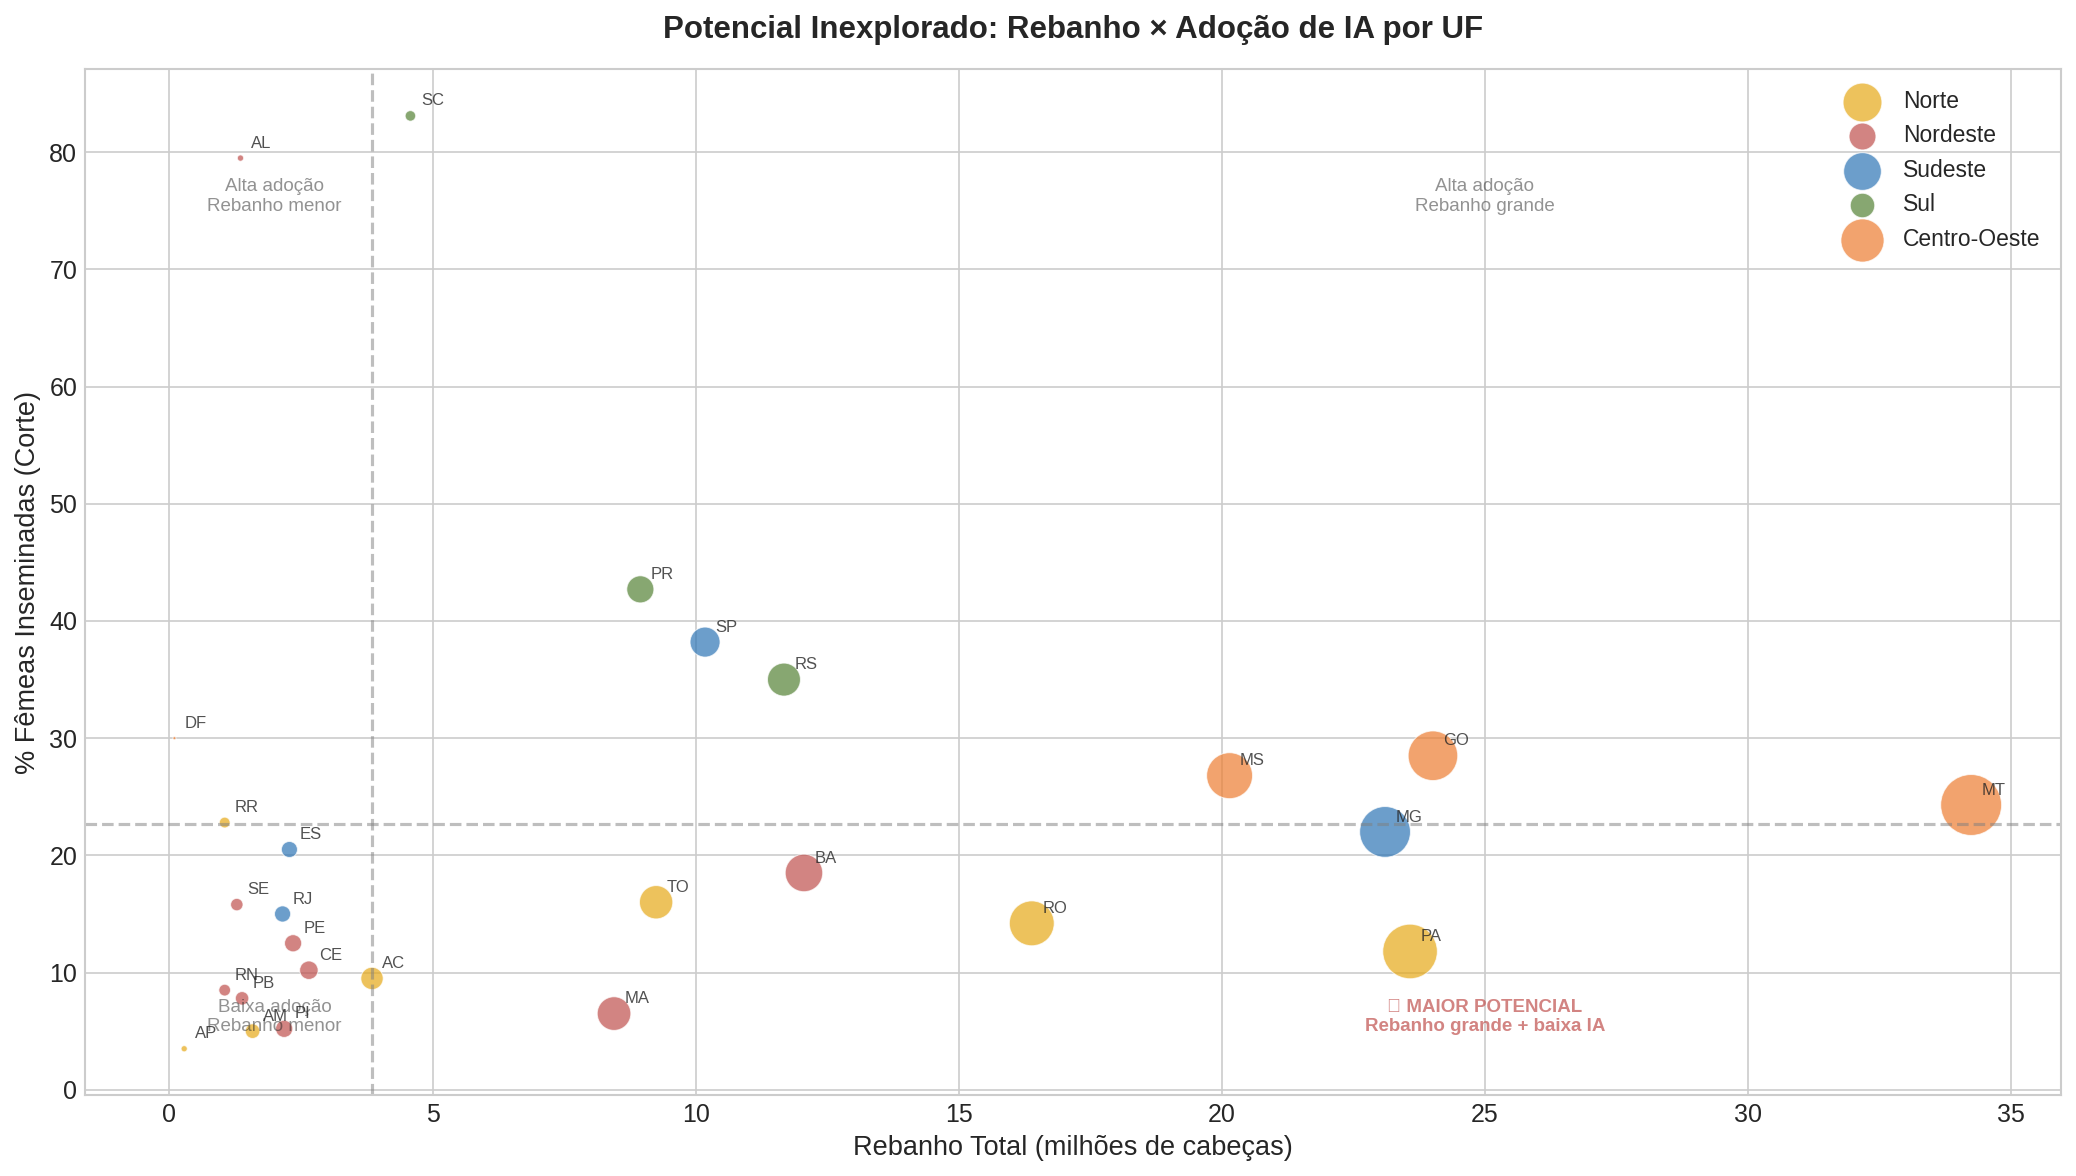

Salvo: plots/05_potencial_scatter.png


In [7]:
fig, ax = plt.subplots(figsize=(14, 8))

for regiao, cor in CORES_REGIAO.items():
    mask = df['regiao'] == regiao
    scatter = ax.scatter(
        df.loc[mask, 'rebanho'] / 1e6,
        df.loc[mask, 'pct_femeas_inseminadas_corte'],
        s=df.loc[mask, 'potencial_doses'] / 5000,  # tamanho proporcional ao potencial
        c=cor, alpha=0.7, edgecolors='white', linewidth=0.5,
        label=regiao
    )

# Labels das UFs
for _, row in df.iterrows():
    ax.annotate(row['sigla_uf'], 
                (row['rebanho']/1e6, row['pct_femeas_inseminadas_corte']),
                textcoords="offset points", xytext=(5, 5), fontsize=8,
                alpha=0.8)

ax.set_xlabel('Rebanho Total (milhões de cabeças)', fontsize=13)
ax.set_ylabel('% Fêmeas Inseminadas (Corte)', fontsize=13)
ax.set_title('Potencial Inexplorado: Rebanho × Adoção de IA por UF', fontsize=15, fontweight='bold', pad=15)

# Quadrantes
ax.axhline(y=media_nac, color=CINZA, linestyle='--', alpha=0.5)
ax.axvline(x=df['rebanho'].median()/1e6, color=CINZA, linestyle='--', alpha=0.5)

# Texto dos quadrantes
ax.text(25, 75, 'Alta adoção\nRebanho grande', fontsize=9, alpha=0.5, ha='center')
ax.text(2, 75, 'Alta adoção\nRebanho menor', fontsize=9, alpha=0.5, ha='center')
ax.text(25, 5, '★ MAIOR POTENCIAL\nRebanho grande + baixa IA', fontsize=9, alpha=0.7, 
        ha='center', color=VERMELHO, fontweight='bold')
ax.text(2, 5, 'Baixa adoção\nRebanho menor', fontsize=9, alpha=0.5, ha='center')

ax.legend(fontsize=11, loc='upper right')
plt.tight_layout()
plt.savefig('plots/05_potencial_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
print('Salvo: plots/05_potencial_scatter.png')

## Gráfico 6 — Mapa Coroplético do Brasil

O mapa é o gráfico mais visual de todos — mostra claramente o gradiente
Norte/Sul na adoção de IA. O Sul e partes do Sudeste/Centro-Oeste em tons
escuros (alta adoção), o Norte e o sertão nordestino em tons claros.

Baixando shapefile do IBGE...


Shapefile carregado: 27 UFs


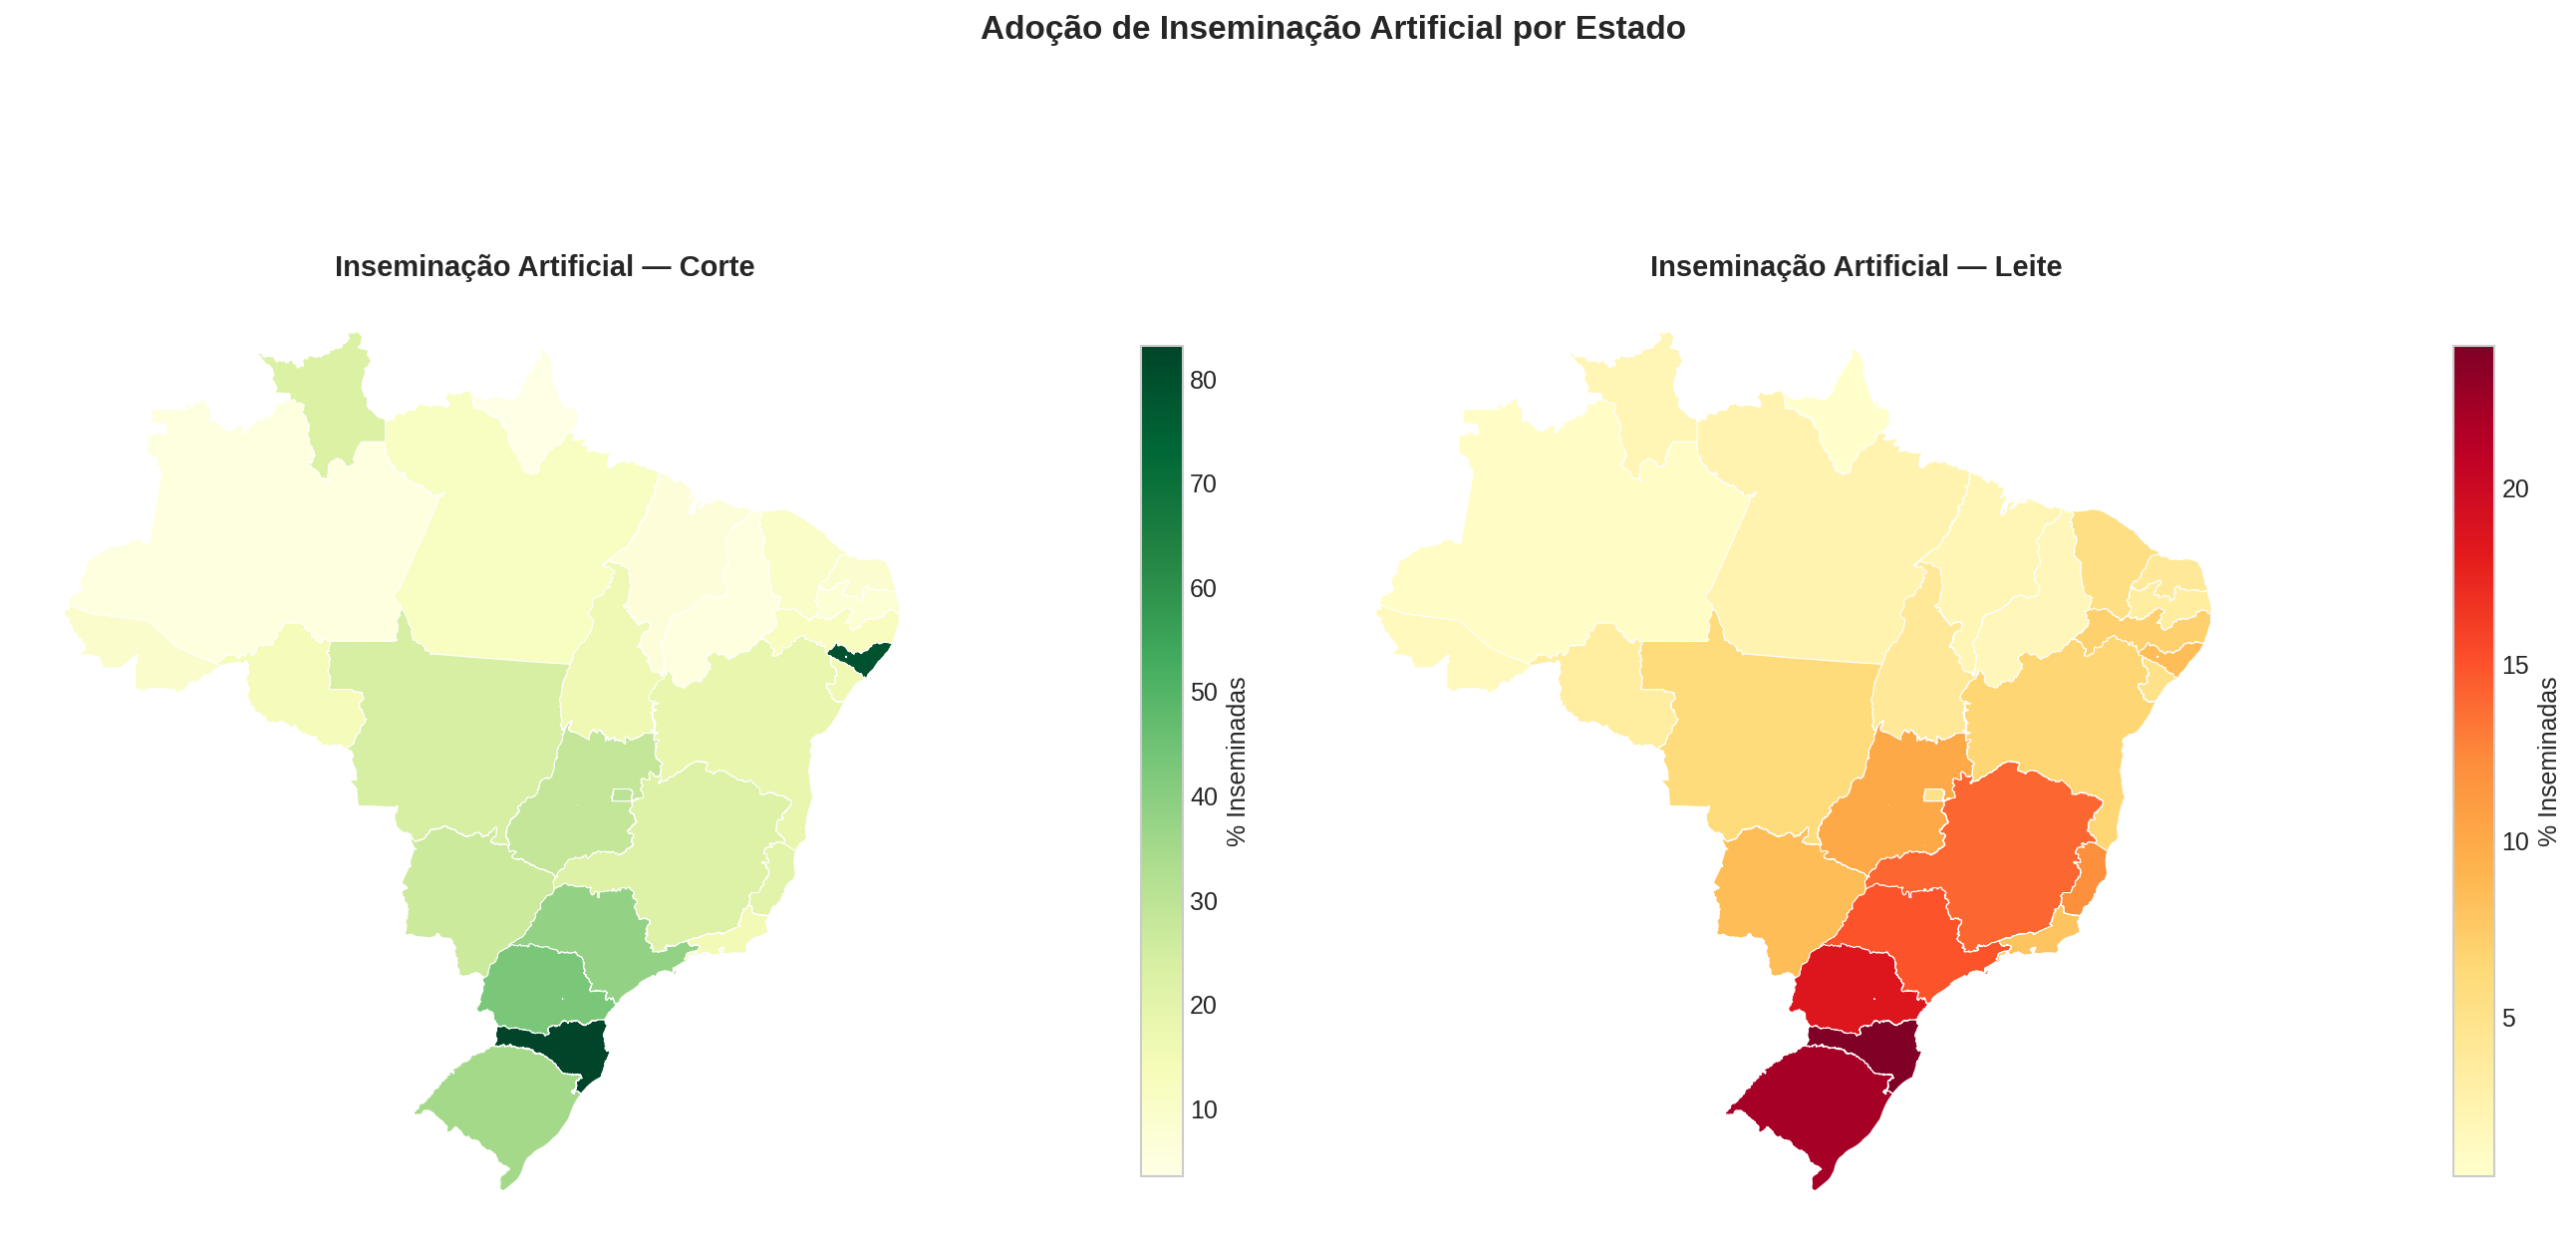

Salvo: plots/06_mapa_coropletico.png


In [8]:
# Mapa coroplético usando geopandas
# Shapefile do IBGE — malha estadual

try:
    import geopandas as gpd
    
    # Tentar baixar direto do IBGE
    url_shape = 'https://geoftp.ibge.gov.br/organizacao_do_territorio/malhas_territoriais/malhas_municipais/municipio_2022/Brasil/BR/BR_UF_2022.zip'
    
    print('Baixando shapefile do IBGE...')
    brasil = gpd.read_file(url_shape)
    print(f'Shapefile carregado: {brasil.shape[0]} UFs')
    
    # Merge com dados
    brasil = brasil.merge(df, left_on='SIGLA_UF', right_on='sigla_uf', how='left')
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 10))
    
    # Mapa 1: Corte
    brasil.plot(column='pct_femeas_inseminadas_corte', cmap='YlGn', ax=ax1,
                legend=True, legend_kwds={'label': '% Inseminadas', 'shrink': 0.6},
                edgecolor='white', linewidth=0.5, missing_kwds={'color': 'lightgrey'})
    ax1.set_title('Inseminação Artificial — Corte', fontsize=14, fontweight='bold')
    ax1.axis('off')
    
    # Mapa 2: Leite
    brasil.plot(column='pct_femeas_inseminadas_leite', cmap='YlOrRd', ax=ax2,
                legend=True, legend_kwds={'label': '% Inseminadas', 'shrink': 0.6},
                edgecolor='white', linewidth=0.5, missing_kwds={'color': 'lightgrey'})
    ax2.set_title('Inseminação Artificial — Leite', fontsize=14, fontweight='bold')
    ax2.axis('off')
    
    fig.suptitle('Adoção de Inseminação Artificial por Estado', fontsize=16, fontweight='bold', y=0.98)
    
    plt.tight_layout()
    plt.savefig('plots/06_mapa_coropletico.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Salvo: plots/06_mapa_coropletico.png')
    
except Exception as e:
    print(f'Erro no mapa: {e}')
    print('\nAlternativa: criando heatmap simples como fallback...')
    
    fig, ax = plt.subplots(figsize=(12, 8))
    
    # Heatmap como alternativa ao mapa
    pivot_data = df.pivot_table(values='pct_femeas_inseminadas_corte', 
                                 index='regiao', columns='sigla_uf',
                                 aggfunc='first')
    
    # Reordenar por região
    regioes_order = ['Sul', 'Sudeste', 'Centro-Oeste', 'Nordeste', 'Norte']
    
    data_heat = df[['sigla_uf', 'pct_femeas_inseminadas_corte', 'regiao']].sort_values(
        ['regiao', 'pct_femeas_inseminadas_corte'], ascending=[True, False])
    
    ax.barh(range(len(data_heat)), data_heat['pct_femeas_inseminadas_corte'],
            color=[CORES_REGIAO[r] for r in data_heat['regiao']])
    ax.set_yticks(range(len(data_heat)))
    ax.set_yticklabels(data_heat['sigla_uf'], fontsize=8)
    ax.set_title('% Fêmeas Inseminadas por UF (fallback sem mapa)', fontsize=14)
    
    plt.tight_layout()
    plt.savefig('plots/06_mapa_coropletico.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Salvo: plots/06_mapa_coropletico.png (fallback)')

## Gráfico 7 — IATF vs Monta Natural: Participação ao Longo do Tempo

Em 2010, a IATF respondia por 55% das inseminações. Em 2024, são 91%.
A IA convencional (com observação de cio) praticamente desapareceu.
A monta natural continua dominando em números absolutos, mas a IATF está
comendo fatia a cada ano.

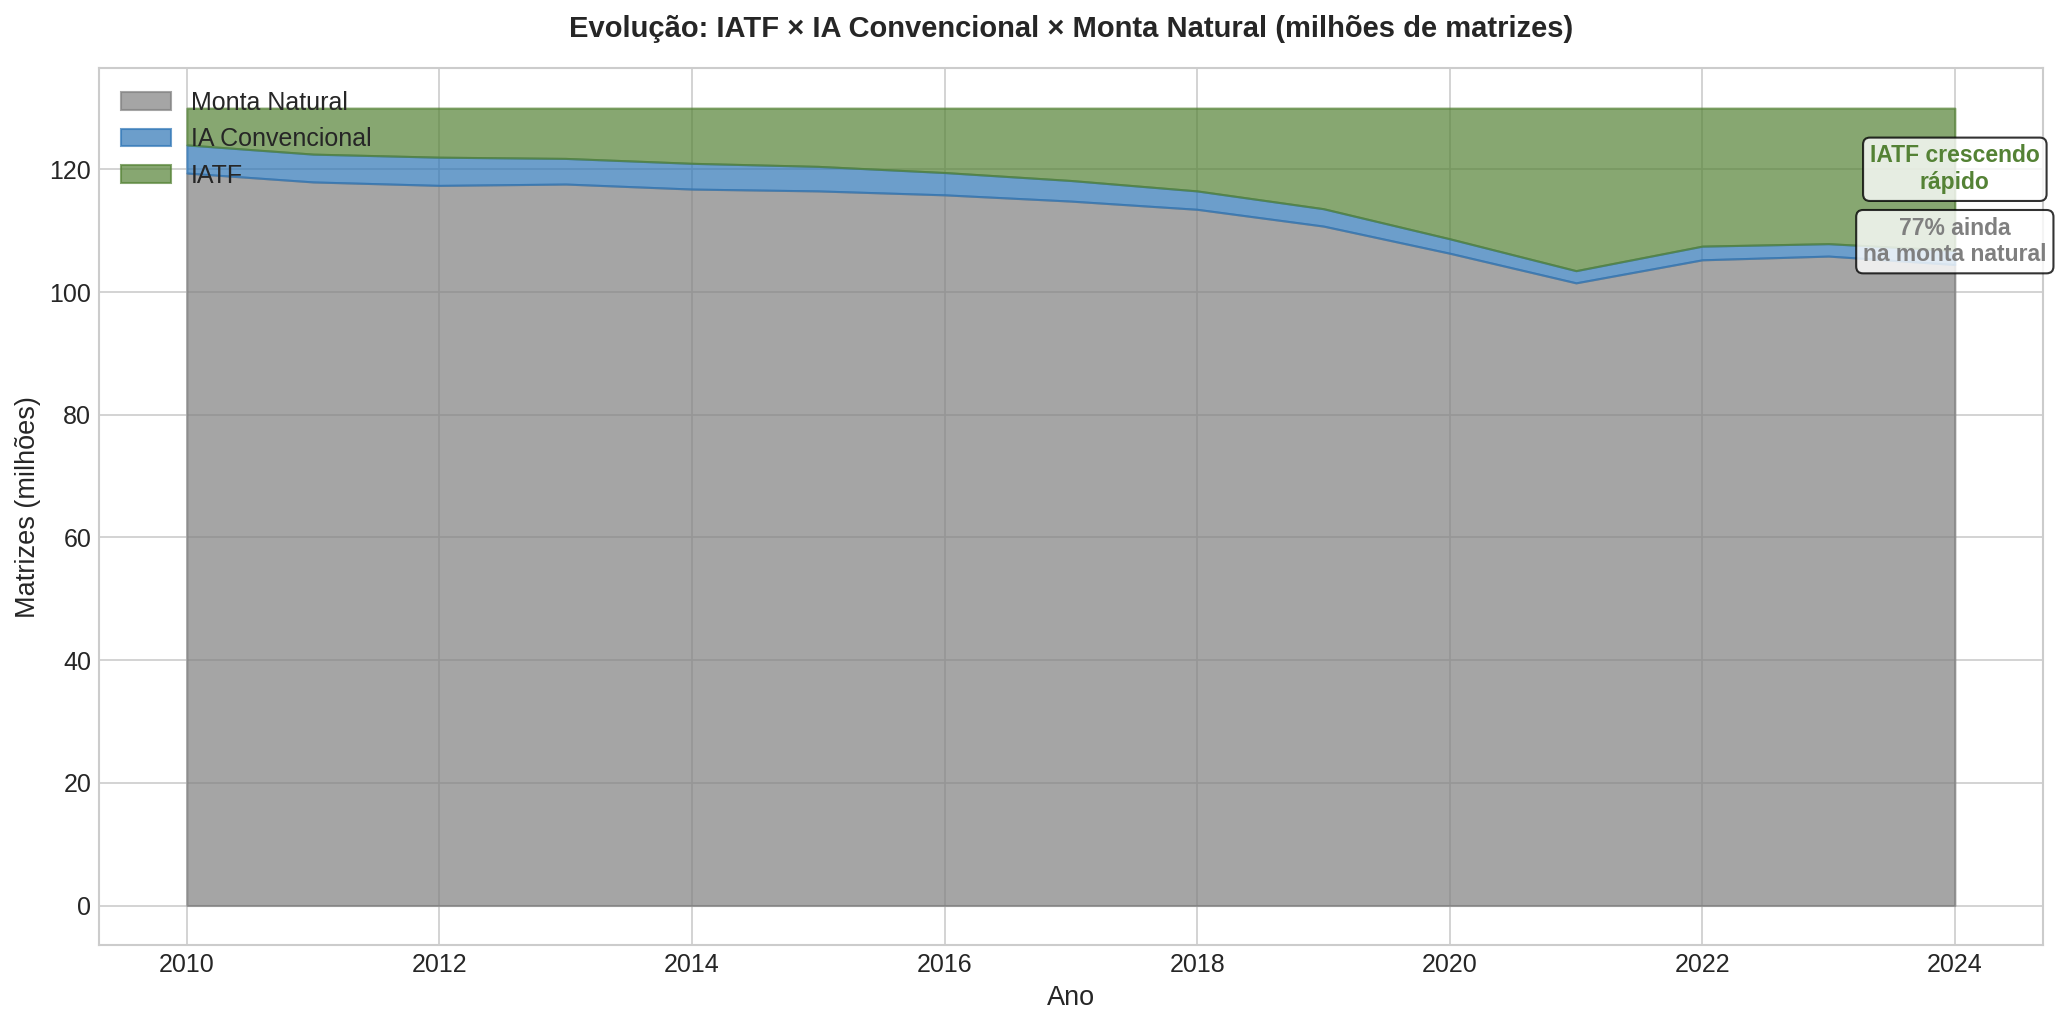

Salvo: plots/07_iatf_vs_monta.png


In [9]:
# Calcular proporções absolutas estimadas
# Total de matrizes ~130M (55% de 238M) — constante simplificada
total_matrizes = 130  # milhões (simplificado)

ab = asbia_brasil.copy()
ab['matrizes_iatf'] = ab['protocolos_iatf_milhoes']  # ~1 protocolo = 1 fêmea
ab['matrizes_ia_conv'] = ab['doses_semen_milhoes'] * (1 - ab['pct_iatf_sobre_ia']/100)
ab['matrizes_monta'] = total_matrizes - ab['matrizes_iatf'] - ab['matrizes_ia_conv']
ab['matrizes_monta'] = ab['matrizes_monta'].clip(lower=0)

fig, ax = plt.subplots(figsize=(14, 7))

ax.fill_between(ab['ano'], 0, ab['matrizes_monta'], alpha=0.7, color=CINZA, label='Monta Natural')
ax.fill_between(ab['ano'], ab['matrizes_monta'], 
                ab['matrizes_monta'] + ab['matrizes_ia_conv'], 
                alpha=0.7, color=AZUL, label='IA Convencional')
ax.fill_between(ab['ano'], ab['matrizes_monta'] + ab['matrizes_ia_conv'],
                ab['matrizes_monta'] + ab['matrizes_ia_conv'] + ab['matrizes_iatf'],
                alpha=0.7, color=VERDE, label='IATF')

ax.set_title('Evolução: IATF × IA Convencional × Monta Natural (milhões de matrizes)', 
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Ano', fontsize=13)
ax.set_ylabel('Matrizes (milhões)', fontsize=13)
ax.legend(fontsize=12, loc='upper left')

# Anotação
ax.annotate('77% ainda\nna monta natural', xy=(2024, 105), fontsize=11,
            color=CINZA, fontweight='bold', ha='center',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

ax.annotate('IATF crescendo\nrápido', xy=(2024, ab.iloc[-1]['matrizes_monta'] + ab.iloc[-1]['matrizes_ia_conv'] + 10),
            fontsize=11, color=VERDE, fontweight='bold', ha='center',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.savefig('plots/07_iatf_vs_monta.png', dpi=150, bbox_inches='tight')
plt.show()
print('Salvo: plots/07_iatf_vs_monta.png')

## Gráfico 8 — Correlação: Preço da Arroba × Protocolos IATF

Esse é o gráfico que todo mundo do setor já sabe intuitivamente, mas agora 
com dados: **quando a arroba sobe, a IATF sobe junto.**

Pecuarista investe em genética quando tem margem. Simples assim.

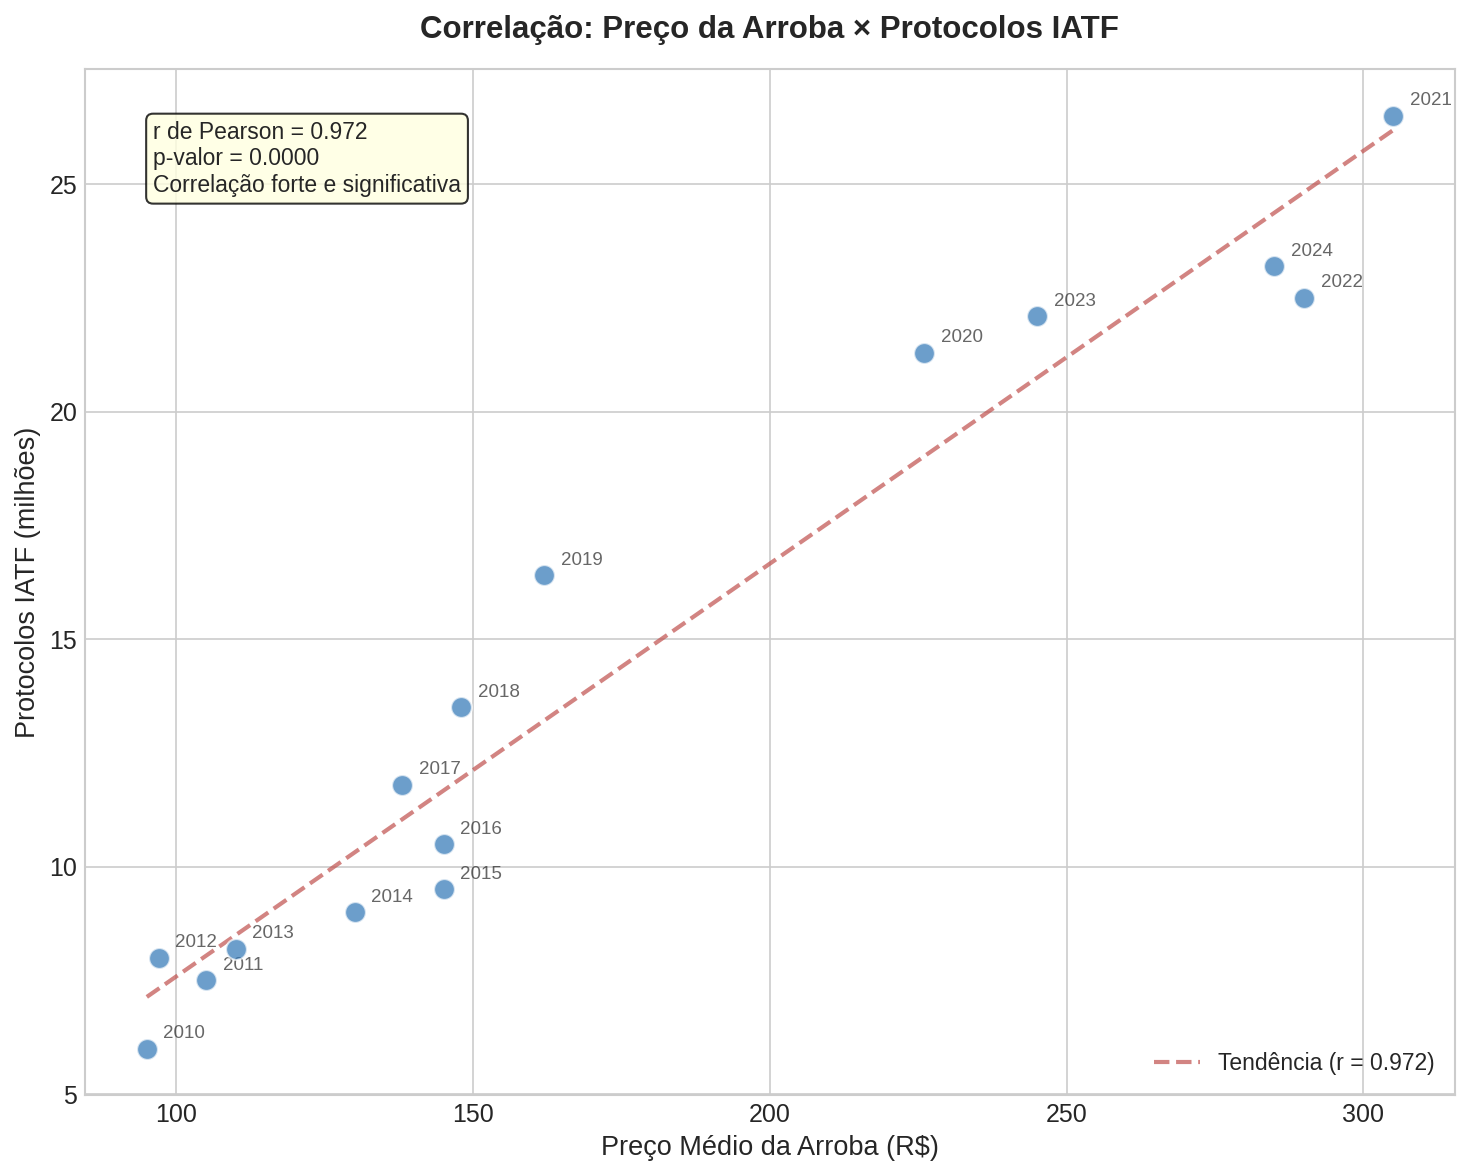

Salvo: plots/08_correlacao_arroba_iatf.png


In [10]:
fig, ax = plt.subplots(figsize=(10, 8))

ax.scatter(asbia_brasil['preco_arroba_media_anual'], 
           asbia_brasil['protocolos_iatf_milhoes'],
           s=100, color=AZUL, alpha=0.7, edgecolors='white', linewidth=1, zorder=5)

# Labels dos anos
for _, row in asbia_brasil.iterrows():
    ax.annotate(str(int(row['ano'])), 
                (row['preco_arroba_media_anual'], row['protocolos_iatf_milhoes']),
                textcoords="offset points", xytext=(8, 5), fontsize=9, alpha=0.7)

# Linha de tendência
slope, intercept, r_value, p_value, std_err = stats.linregress(
    asbia_brasil['preco_arroba_media_anual'], 
    asbia_brasil['protocolos_iatf_milhoes']
)
x_line = np.linspace(asbia_brasil['preco_arroba_media_anual'].min(), 
                      asbia_brasil['preco_arroba_media_anual'].max(), 100)
ax.plot(x_line, slope * x_line + intercept, color=VERMELHO, linewidth=2, 
        linestyle='--', alpha=0.7, label=f'Tendência (r = {r_value:.3f})')

ax.set_xlabel('Preço Médio da Arroba (R$)', fontsize=13)
ax.set_ylabel('Protocolos IATF (milhões)', fontsize=13)
ax.set_title('Correlação: Preço da Arroba × Protocolos IATF', fontsize=15, fontweight='bold', pad=15)

# Box com estatísticas
textstr = f'r de Pearson = {r_value:.3f}\np-valor = {p_value:.4f}\n{"Correlação forte e significativa" if p_value < 0.05 else ""}'
props = dict(boxstyle='round', facecolor='lightyellow', alpha=0.8)
ax.text(0.05, 0.95, textstr, transform=ax.transAxes, fontsize=11,
        verticalalignment='top', bbox=props)

ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig('plots/08_correlacao_arroba_iatf.png', dpi=150, bbox_inches='tight')
plt.show()
print('Salvo: plots/08_correlacao_arroba_iatf.png')

## Resumo dos Gráficos

Todos os 8 gráficos foram salvos na pasta `plots/`. Principais insights:

1. A IATF cresceu 4x em 14 anos (2010→2024)
2. O investimento em IATF acompanha diretamente o preço da arroba
3. O Sul lidera em adoção, Norte e Nordeste ficam abaixo da média
4. Alagoas é o outlier surpreendente — 79,5%, 2º lugar nacional
5. PA, BA, MA têm o maior potencial absoluto inexplorado
6. O mapa mostra claramente o gradiente geográfico da adoção
7. A IATF dominou: 91% das IAs são por protocolo de tempo fixo
8. Correlação arroba × IATF é forte e significativa

Agora vou aprofundar a análise do Nordeste no notebook 03.